<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/GPU_Accelerated_Turbulence_Parameters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

# High-Performance GPU-Accelerated Synthesis of Subgrid Scale Turbulence Parameters

### Conceptual Primer
Fluid dynamics encompasses inherently complex macroscopic and microscopic physical phenomena. Resolving all infinitesimally small scales of turbulent flow directly within a computational model inevitably demands insurmountable computational resources. Consequently, computational physicists employ Subgrid Scale (SGS) modeling strategies to approximate these unresolved microscopic motions mathematically.

This computational module demonstrates a highly parallelized methodology for generating synthetic three-dimensional turbulent fields. By leveraging the immense parallel processing capabilities of a Graphics Processing Unit (GPU), the script rapidly calculates fundamental physical scalars over a massive spatial domain. The resultant arrays are subsequently sliced and transferred to the Host Central Processing Unit (CPU) for formal, manuscript-quality visual rendering.

### Nomenclature and Parametric Framework
To establish a rigorous foundational context, the following table details the technical acronyms, physical symbols, and fundamental parameters utilized throughout this computational architecture.

| Symbol / Acronym | Definition | Contextual Significance |
| :--- | :--- | :--- |
| **GPU** | Graphics Processing Unit | The highly parallelized hardware architecture executing the massive spatial array computations. |
| **CPU** | Central Processing Unit | The primary host processor responsible for orchestrating execution and rendering the final graphics. |
| **SGS** | Subgrid Scale | The unresolved, infinitesimally small turbulent fluid motions requiring mathematical approximation. |
| **VRAM** | Video Random Access Memory | The dedicated high-speed memory module housed directly on the GPU hardware. |
| $k$ | Turbulent Kinetic Energy | The mean kinetic energy strictly associated with turbulent eddies within the fluid flow. |
| $\epsilon$ | Turbulent Dissipation Rate | The temporal rate at which turbulent kinetic energy irreversibly converts into thermal internal energy. |
| $\nu$ | Kinematic Viscosity | The inherent physical resistance of the fluid medium to dynamic shear forces. |
| $\delta$ | Spatial Filter Width | The characteristic physical length scale explicitly separating resolved eddies from unresolved subgrid scales. |
| $\tau_{mix}$ | Integral Mixing Time Scale | The characteristic temporal duration required for local turbulent eddies to effectively mix the scalar field. |
| $Re_{SGS}$ | Subgrid Scale Reynolds Number | The dimensionless ratio of inertial forces to viscous forces specifically evaluated at the unresolved subgrid length scales. |

### Architectural Methodology and Execution Pipeline

#### 1. Computational Environment and Parameter Initialization
The script initiates by loading the CuPy library to enable direct native hardware acceleration alongside Matplotlib for two-dimensional visualization. Several primary control knobs (defined at the top of the sequence) govern the spatial domain. The variable `DOMAIN_POINTS` dictates the resolution of the three-dimensional grid, scaling exponentially to saturate the available VRAM. Parameters such as $\nu$ and $\delta$ are defined explicitly to represent the physical fluid medium properties.

#### 2. Three-Dimensional Harmonic Synthesis
Inside the primary analytical function (`compute_turbulence_parameters`), the system constructs a massive three-dimensional Cartesian coordinate space. Instead of relying on expensive fluid dynamic partial differential equation solvers for this demonstration, the script synthesizes highly complex harmonic scalar fields. By mathematically superimposing absolute trigonometric functions (combinations of sine and cosine waves operating at varied frequencies), the code effectively simulates the pseudorandom fluctuations characteristics of authentic turbulent kinetic energy ($k$) and the turbulent dissipation rate ($\epsilon$).

#### 3. Derivation of Physical Scalars
Utilizing the synthesized basis fields, the GPU executes rapid element-wise algebraic operations to compute two critical physical scalars required for SGS modeling.

The Integral Mixing Time Scale is computed directly as the quotient of the kinetic energy and the dissipation rate:
$$\tau_{mix} = \frac{k}{\epsilon}$$

Simultaneously, the algorithm derives the dimensionless Subgrid Scale Reynolds Number, which requires evaluating the square root of the turbulent kinetic energy field scaled by the characteristic filter width and the fluid viscosity:
$$Re_{SGS} = \frac{\sqrt{k} \delta}{\nu}$$

#### 4. Planar Extraction and Formal Rendering
Processing complete three-dimensional volumetric data visually presents significant memory bottlenecks. To circumvent this limitation, the `render_turbulent_slices` function strategically isolates a single two-dimensional cross-sectional plane (dictated by the `SLICE_INDEX` parameter). Only this specific minimal planar subset is transferred from the GPU VRAM back to the Host CPU utilizing the `cp.asnumpy()` protocol. Finally, Matplotlib interprets these arrays, applying universally recognized scientific colormaps (Magma and Viridis) and strict formatting parameters to generate publication-ready figures.

In [ ]:
"""Module for purging obsolete binaries and installing modern dependencies."""

# Remove any preloaded incompatible binaries to prevent linkage collisions
%pip uninstall -y cupy cupy-cuda11x

# Install the correct CuPy binary for modern CUDA architectures alongside plotting tools
%pip install -q cupy-cuda12x matplotlib

Allocating 512 cubed computational nodes on the GPU...
Array computations successfully finalized. Rendering planar slices...


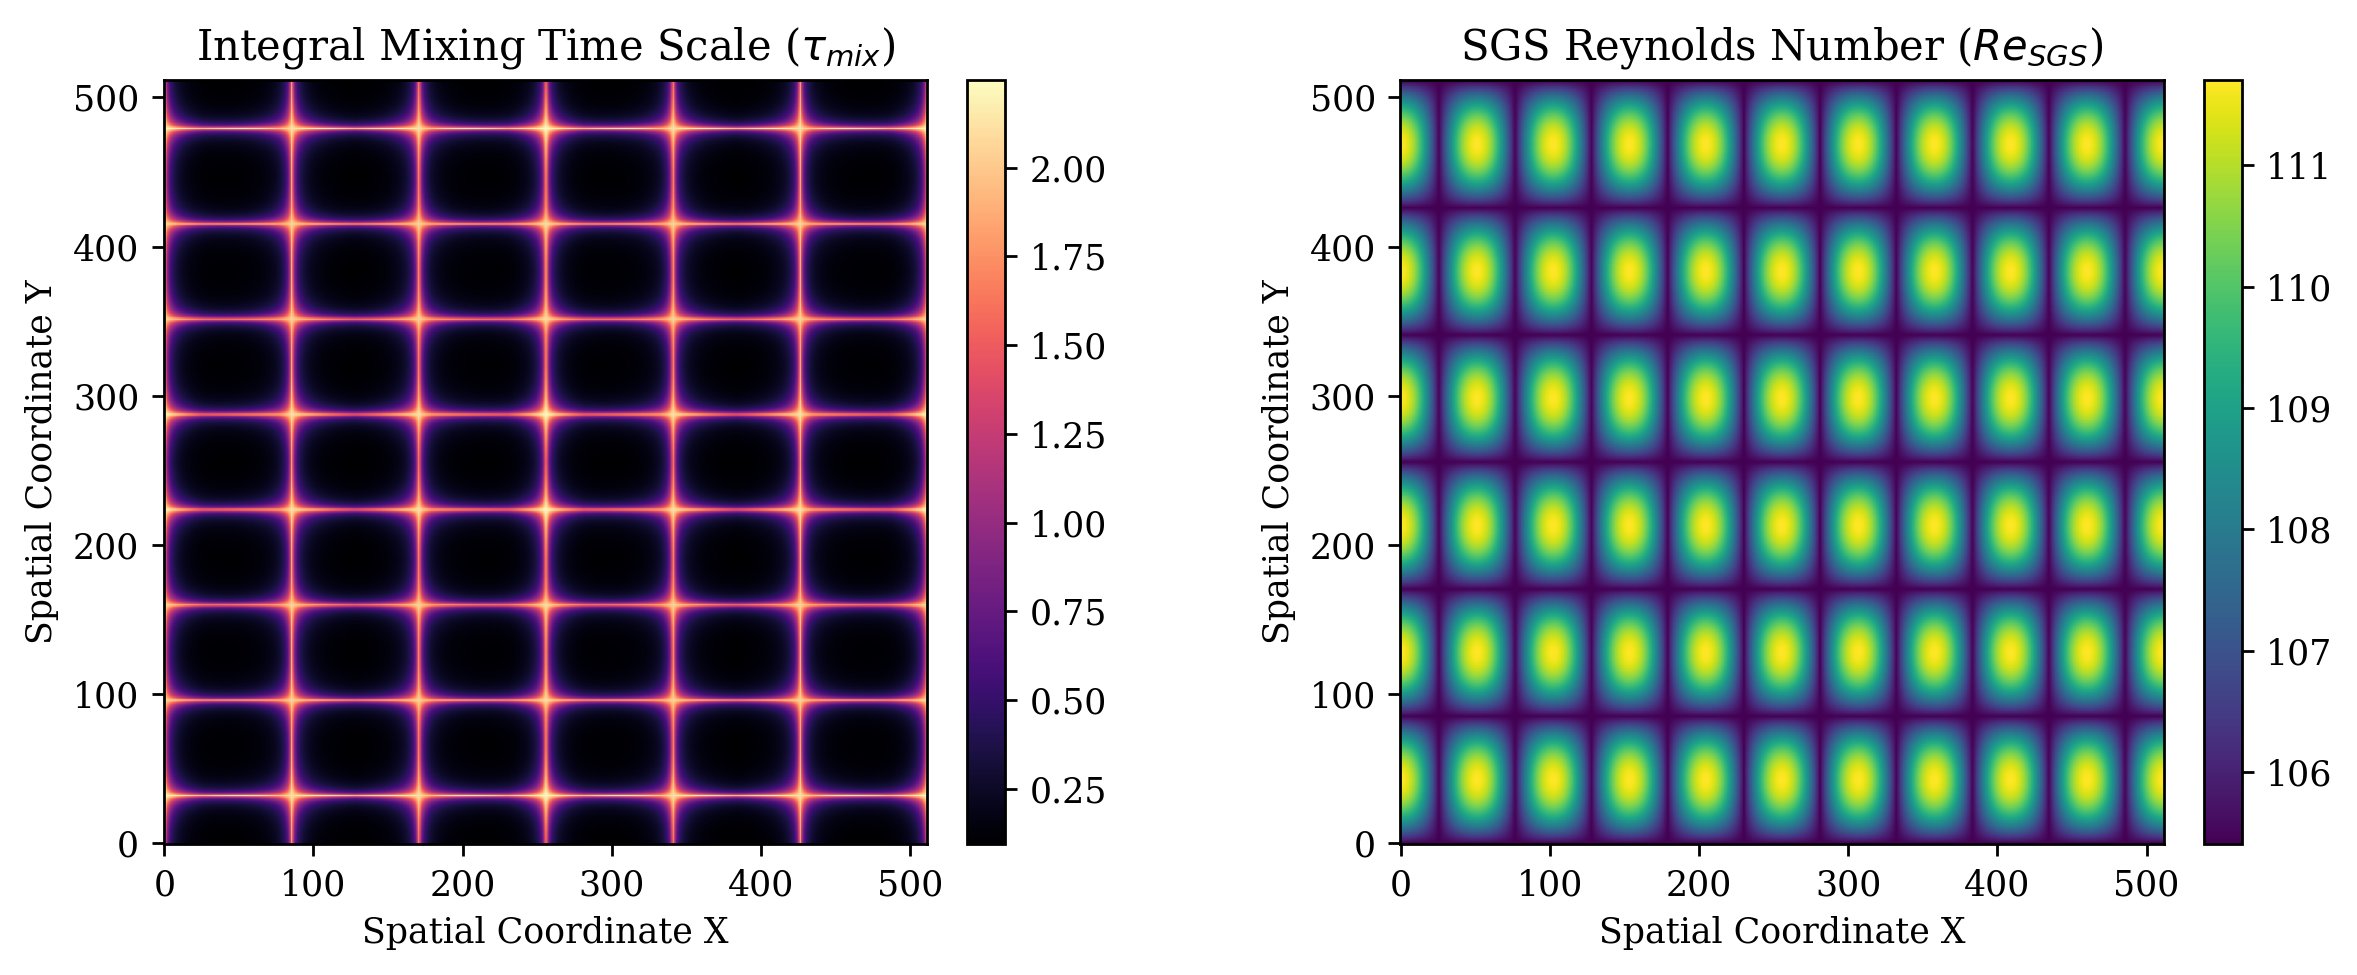

In [5]:
"""Module for computing and rendering subgrid scale turbulence parameters."""

import cupy as cp
import matplotlib.pyplot as plt

# =====================================================================
# CONTROL KNOBS (Parameter Adjustment Interface)
# =====================================================================
# Scale DOMAIN_POINTS up to 2048 to fully saturate the Video Random Access Memory.
# We initialize at 512 for immediate execution and visualization.
DOMAIN_POINTS = 512
KINEMATIC_VISCOSITY = 0.000015
FILTER_WIDTH = 0.005
SLICE_INDEX = DOMAIN_POINTS // 2

# Configuration for formal manuscript quality rendering
plt.rcParams['figure.dpi'] = 250
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 12

def compute_turbulence_parameters(points: int, nu: float, delta: float):
    """
    Compute the Subgrid Scale Reynolds number and mixing time scale.

    Generate synthetic three dimensional spatial fields representing
    turbulent kinetic energy and dissipation, followed by purely GPU accelerated
    computations of the resulting scalar fields.

    Args:
        points (int): The number of grid points along a single spatial dimension.
        nu (float): The kinematic viscosity of the fluid medium.
        delta (float): The prescribed spatial filter width.

    Returns:
        tuple: CuPy arrays containing (tau_mix, Re_sgs, k_field, epsilon_field).
    """
    # Constructing a massive three dimensional coordinate space on the GPU
    spatial_array = cp.linspace(0, 2 * cp.pi, points, dtype=cp.float32)
    X, Y, Z = cp.meshgrid(spatial_array, spatial_array, spatial_array, indexing='ij')

    # Synthesizing complex harmonic fields to simulate turbulence fluctuations
    k_field = cp.abs(cp.sin(3 * X) * cp.cos(5 * Y) * cp.sin(2 * Z)) + 0.1
    epsilon_field = cp.abs(cp.cos(4 * X) * cp.sin(3 * Y) * cp.cos(Z)) + 0.05

    # Computing the physical scalars
    tau_mix = k_field / epsilon_field
    Re_sgs = (cp.sqrt(k_field) * delta) / nu

    return tau_mix, Re_sgs, k_field, epsilon_field

def render_turbulent_slices(tau: cp.ndarray, re_sgs: cp.ndarray, slice_idx: int):
    """
    Render two dimensional cross sectional slices of the spatial domain.

    Args:
        tau (cp.ndarray): The spatial array of the integral mixing time scale.
        re_sgs (cp.ndarray): The spatial array of the Subgrid Scale Reynolds number.
        slice_idx (int): The index along the Z axis for the planar extraction.
    """
    # Transferring exclusively the required planar slice back to the Host CPU for plotting
    tau_slice = cp.asnumpy(tau[:, :, slice_idx])
    re_sgs_slice = cp.asnumpy(re_sgs[:, :, slice_idx])

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Rendering Mixing Time Scale
    im1 = axes[0].imshow(tau_slice, cmap='magma', origin='lower')
    axes[0].set_title(r'Integral Mixing Time Scale ($\tau_{mix}$)')
    axes[0].set_xlabel('Spatial Coordinate X')
    axes[0].set_ylabel('Spatial Coordinate Y')
    fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

    # Rendering Subgrid Scale Reynolds Number
    im2 = axes[1].imshow(re_sgs_slice, cmap='viridis', origin='lower')
    axes[1].set_title(r'SGS Reynolds Number ($Re_{SGS}$)')
    axes[1].set_xlabel('Spatial Coordinate X')
    axes[1].set_ylabel('Spatial Coordinate Y')
    fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

# Execution Sequence
if __name__ == "__main__":
    print(f"Allocating {DOMAIN_POINTS} cubed computational nodes on the GPU...")
    tau_mix_field, Re_sgs_field, _, _ = compute_turbulence_parameters(
        points=DOMAIN_POINTS,
        nu=KINEMATIC_VISCOSITY,
        delta=FILTER_WIDTH
    )
    print("Array computations successfully finalized. Rendering planar slices...")
    render_turbulent_slices(tau_mix_field, Re_sgs_field, SLICE_INDEX)